## YOY Growth Data

In [1]:
# Import necessary libraries
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown
from datetime import date
import calplot
import glob
import json
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pyarrow  # Pandas 3: PyArrow backend for faster string operations
import warnings
import os
import seaborn as sns
import subprocess

# Register a cell magic for Markdown
@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# Configure logging and warnings
logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings("ignore")

# Set pandas display options
pd.set_option('display.width', 500)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 10)

# Set the path to the shared data file
data_path = '../data/nvd.jsonl'
if not os.path.exists(data_path):
    print(f"Data file not found at {data_path}. Attempting to download...")
    try:
        subprocess.run(['python', '../download_data.py'], check=True)
    except Exception as e:
        print(f"Download script failed: {e}")
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data file not found at {data_path} after attempting download. Please check your setup.")

In [2]:
def get_nested_value(entry, keys, default='Missing_Data'):
    try:
        for key in keys:
            entry = entry[key]
        return entry
    except (KeyError, IndexError):
        return default

row_accumulator = []
for filename in glob.glob(data_path):
    with open(filename, 'r', encoding='utf-8') as f:
        nvd_data = json.load(f)
        for entry in nvd_data:
            new_row = {
                'CVE': get_nested_value(entry, ['cve', 'id']),
                'Published': get_nested_value(entry, ['cve', 'published']),
                'AttackVector': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackVector']),
                'AttackComplexity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackComplexity']),
                'PrivilegesRequired': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'privilegesRequired']),
                'UserInteraction': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'userInteraction']),
                'Scope': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'scope']),
                'ConfidentialityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'confidentialityImpact']),
                'IntegrityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'integrityImpact']),
                'AvailabilityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'availabilityImpact']),
                'BaseScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseScore'], '0.0'),
                'BaseSeverity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseSeverity']),
                'ExploitabilityScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'exploitabilityScore']),
                'ImpactScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'impactScore']),
                'CWE': get_nested_value(entry, ['cve', 'weaknesses', 0, 'description', 0, 'value']),
                'Description': get_nested_value(entry, ['cve', 'descriptions', 0, 'value'], ''),
                'Assigner': get_nested_value(entry, ['cve', 'sourceIdentifier']),
                'Tag': get_nested_value(entry, ['cve', 'cveTags', 0, 'tags'], np.nan),
                'Status': get_nested_value(entry, ['cve', 'vulnStatus'], '')
            }
            row_accumulator.append(new_row)

nvd = pd.DataFrame(row_accumulator)

nvd = nvd[~nvd.Status.str.contains('Rejected')]
nvd['Published'] = pd.to_datetime(nvd['Published'])
Year_2026 = ((nvd['Published'] > '2026-01-01') & (nvd['Published']  < '2026-02-01'))
Year_2025 = ((nvd['Published'] > '2025-01-01') & (nvd['Published']  < '2025-02-01'))


nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore']);
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore']);
nvd['BaseScore'] = nvd['BaseScore'].replace(0, np.nan);

nvd_2026 = nvd.loc[Year_2026]
nvd_2026 = nvd_2026.sort_values(by=['Published'])
nvd_2026 = nvd_2026.reset_index(drop=True)
nvdcount_2026 = nvd_2026['Published'].count()

nvd_2025 = nvd.loc[Year_2025]
nvd_2025 = nvd_2025.sort_values(by=['Published'])
nvd_2025 = nvd_2025.reset_index(drop=True)
nvdcount_2025 = nvd_2025['Published'].count()


In [3]:
Day_2025 = nvd_2025['Published'].groupby(nvd_2025.Published.dt.to_period("D")).agg('count')
Day_2026 = nvd_2026['Published'].groupby(nvd_2026.Published.dt.to_period("D")).agg('count')

Day_2025 = Day_2025.reset_index(name="2025")
Day_2025 = Day_2025.rename(columns={"Published": "Day"}, errors="raise")
Day_2025['Day'] = Day_2025['Day'].dt.strftime('%B-%d')

Day_2026 = Day_2026.reset_index(name="2026")
Day_2026 = Day_2026.rename(columns={"Published": "Day"}, errors="raise")
Day_2026['Day'] = Day_2026['Day'].dt.strftime('%B-%d')

Days = pd.merge(Day_2025, Day_2026, how='left')

# Replace NaN values with 0 and round 2026 values to the nearest integer
Days = Days.fillna(0)
Days['2026'] = Days['2026'].round().astype(int)

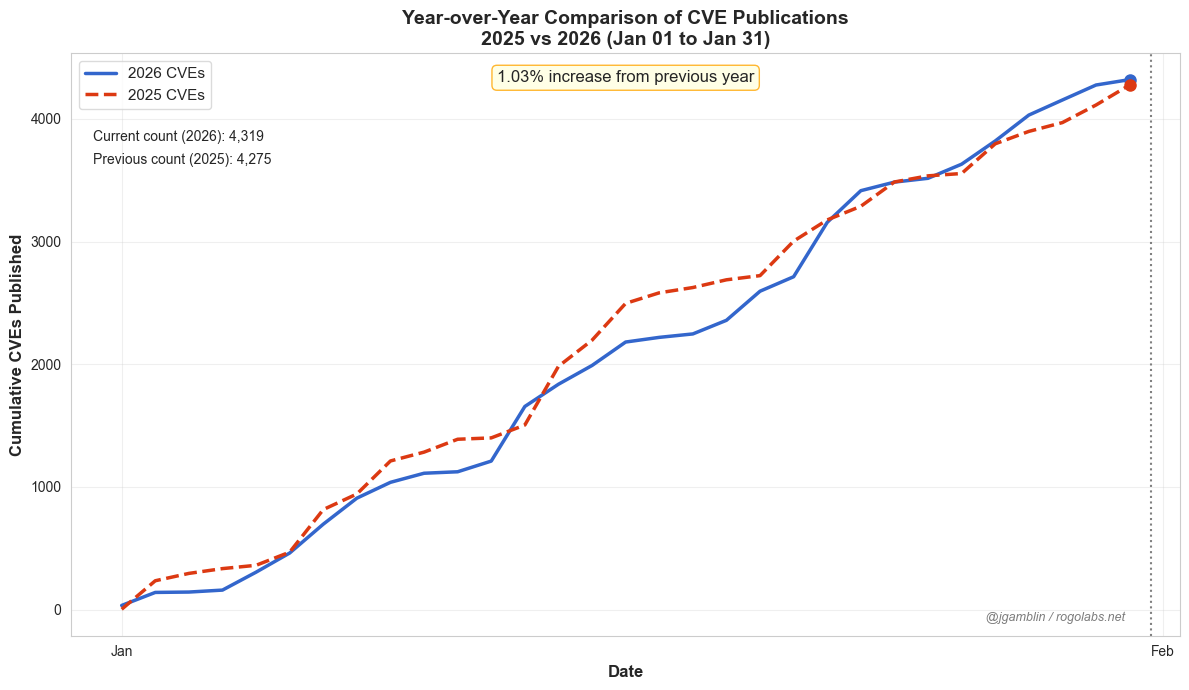

In [6]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'

# Define current and previous year for use in plotting
current_year = 2026
previous_year = 2025

# Use the boolean masks already defined
current_year_data = nvd[Year_2026]
previous_year_data = nvd[Year_2025]

# Create a function to get cumulative counts by day of year
def get_cumulative_by_doy(data, year):
    daily_counts = data.groupby(data['Published'].dt.dayofyear).size()
    all_days = pd.Series(range(1, 367))
    daily_counts = daily_counts.reindex(all_days, fill_value=0)
    cumulative = daily_counts.cumsum()
    dates = pd.date_range(start=f'{year}-01-01', periods=366)
    return dates, cumulative

current_dates, current_cumulative = get_cumulative_by_doy(current_year_data, current_year)
previous_dates, previous_cumulative = get_cumulative_by_doy(previous_year_data, previous_year)

# Normalize previous year dates to current year for proper alignment
normalized_previous_dates = []
for d in previous_dates:
    try:
        normalized_previous_dates.append(d.replace(year=current_year))
    except ValueError:
        if d.month == 2 and d.day == 29:
            continue

if len(normalized_previous_dates) < len(previous_cumulative):
    normalized_previous_dates.append(pd.Timestamp(f'{current_year}-12-31'))

# Find the last day of year with data for 2026
if not current_year_data.empty:
    last_doy = current_year_data['Published'].dt.dayofyear.max()
    current_cumulative = current_cumulative.iloc[:last_doy]
    current_dates = current_dates[:last_doy]
    previous_cumulative = previous_cumulative.iloc[:last_doy]
    normalized_previous_dates = normalized_previous_dates[:last_doy]

# Use the last available day in current_year_data for slicing
# Instead of slicing, use the full cumulative series up to the last available date
# This ensures the count matches the data output
current_cumulative = current_cumulative  # No slicing
current_dates = current_dates  # No slicing
previous_cumulative = previous_cumulative.iloc[:len(current_cumulative)]
normalized_previous_dates = normalized_previous_dates[:len(current_cumulative)]

fig, ax = plt.subplots()
ax.plot(current_dates, current_cumulative, linewidth=2.5, color='#3366CC', 
        label=f'{current_year} CVEs')
ax.plot(normalized_previous_dates, previous_cumulative, linewidth=2.5, color='#DC3912', 
        linestyle='--', label=f'{previous_year} CVEs')
ax.plot(current_dates[-1], current_cumulative.iloc[-1], 'o', color='#3366CC', markersize=8)
ax.plot(normalized_previous_dates[-1], previous_cumulative.iloc[-1], 'o', color='#DC3912', markersize=8)

if previous_cumulative.iloc[-1] > 0:
    # Use the same calculation as the summary cell for consistency
    percent_change = ((current_cumulative.iloc[-1] - previous_cumulative.iloc[-1]) / previous_cumulative.iloc[-1]) * 100
    change_text = f"{percent_change:.2f}% {'increase' if percent_change > 0 else 'decrease'} from previous year"
    ax.annotate(change_text, 
                xy=(0.5, 0.95), 
                xycoords='axes fraction', 
                ha='center',
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.8))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Draw a vertical line at the last date in current_year_data
if not current_year_data.empty:
    last_date = current_year_data['Published'].max()
    ax.axvline(last_date, linestyle=':', color='gray')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative CVEs Published', fontsize=12, fontweight='bold')

# Get the min and max date for the current year data for the title
if not current_year_data.empty:
    min_date = current_year_data['Published'].min().strftime('%b %d')
    # Add one day to the max date for the range
    max_date_plus_one = (current_year_data['Published'].max() + pd.Timedelta(days=0)).strftime('%b %d')
    date_range_str = f"({min_date} to {max_date_plus_one})"
else:
    date_range_str = ""

ax.set_title(f'Year-over-Year Comparison of CVE Publications\n{previous_year} vs {current_year} {date_range_str}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
legend = ax.legend(loc='upper left', frameon=True, fontsize=11)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_alpha(0.8)
frame.set_edgecolor('lightgray')
# Use the last value of the cumulative series for the count, as this reflects the true cumulative CVEs published (including days with zero CVEs)
current_count = int(current_cumulative.iloc[-1]) if len(current_cumulative) > 0 else 0
previous_count = int(previous_cumulative.iloc[-1]) if len(previous_cumulative) > 0 else 0
ax.annotate(f'Current count ({current_year}): {current_count:,}', 
            xy=(0.02, 0.85), xycoords='axes fraction', fontsize=10)
ax.annotate(f'Previous count ({previous_year}): {int(previous_count):,}', 
            xy=(0.02, 0.81), xycoords='axes fraction', fontsize=10)

# Add watermark in bottom right corner
ax.annotate('@jgamblin / rogolabs.net', 
            xy=(0.95, 0.02), 
            xycoords='axes fraction', 
            ha='right', 
            va='bottom',
            fontsize=9,
            alpha=0.6,
            style='italic')

plt.tight_layout()
output_filename = f'YOY_CVE_Comparison_{current_year}_vs_{previous_year}.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
logging.info(f"Plot saved as {output_filename}")
plt.show()

In [5]:
# Function to convert a day to its ordinal representation
def ordinal(n):
    return f"{n}{'th' if 11 <= (n % 100) <= 13 else {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')}"


# Calculate total number of CVEs in 2026
total_cves_2026 = nvd_2026.shape[0]

# Calculate total number of CVEs in 2025
total_cves_2025 = nvd_2025.shape[0]

# Use the same count as the graph (last value of current_cumulative)
graph_total_cves_2026 = int(current_cumulative.iloc[-1]) if len(current_cumulative) > 0 else 0
# Use the same for 2025
graph_total_cves_2025 = int(previous_cumulative.iloc[-1]) if len(previous_cumulative) > 0 else 0

# Calculate average CVEs per day in 2026 (use the number of days in the graph)
graph_days_2026 = len(current_cumulative)
graph_average_cves_per_day_2026 = graph_total_cves_2026 / graph_days_2026 if graph_days_2026 > 0 else 0

# Calculate YOY growth using graph counts
graph_yoy_growth = ((graph_total_cves_2026 - graph_total_cves_2025) / graph_total_cves_2025) * 100 if graph_total_cves_2025 > 0 else 0
graph_yoy_growth_count = graph_total_cves_2026 - graph_total_cves_2025

# Calculate average CVSS score for 2026
average_cvss_score_2026 = nvd_2026['BaseScore'].mean() if not nvd_2026.empty else 0

# Use the last date in the graph for the output date
if len(current_dates) > 0:
    graph_end_date = current_dates[-1].date()
else:
    graph_end_date = end_date_2026

output = f"""
2026 CVE Stats Update ({graph_end_date.strftime('%B')} {ordinal(graph_end_date.day)}, {graph_end_date.year})
Total Number of CVEs: {graph_total_cves_2026}
Average CVEs Per Day: {graph_average_cves_per_day_2026:.2f}
Average CVSS Score: {average_cvss_score_2026:.2f}
YOY Growth: {graph_yoy_growth:.2f}% or +{graph_yoy_growth_count} ({graph_total_cves_2025} CVEs in 2025)
"""

print(output)


2026 CVE Stats Update (January 31st, 2026)
Total Number of CVEs: 4319
Average CVEs Per Day: 139.32
Average CVSS Score: 6.89
YOY Growth: 1.03% or +44 (4275 CVEs in 2025)

